# Attempted Improvements: Reducing the False-Positive Rate

Week 10 validation surfaced the defense's real weakness: an honest-client false-positive rate of **20.5%** (honest clients wrongly flagged as suspicious), and it showed that our trust gate is tuned the wrong way (a sharper gate makes things worse). This notebook attempts to fix that, and reports honestly whether each fix actually helps.

**The root cause.** Our trust score is `trust = clean_accuracy * exp(-beta * suspicion)`, applied to every client every round, where suspicion is how anomalously bad a client is at detecting spoofing on any single probe feature (a robust MAD z-score against the cohort). Two things make honest clients get punished:
1. The gate penalizes *any* positive suspicion continuously, so an honest client that is merely the noisiest of a tight cluster still loses trust.
2. Trust is a relative per-round ranking, so somebody is always at the bottom, and a transient dip in one round is treated the same as a persistent problem.

**Three fixes, ablated one at a time (all across seeds 42, 7, 123):**

- **D0 Baseline** = the current defense (beta = 2.0, no dead-zone, no persistence). Reproduces the Week 10 numbers.
- **D1 = + gentler gate (beta = 1.0).** Week 10 already found this dominates beta = 2.0.
- **D2 = + suspicion dead-zone (tau = 2.0).** Only penalize the part of suspicion *above* a threshold, so honest noise below tau is ignored and only genuine outliers (attackers) are gated.
- **D3 = + consecutive-round persistence (k = 2).** Only down-weight a client that stays above the dead-zone for two rounds in a row. Attackers are flagged every round (persistent); honest dips are transient, so this should protect honest clients while barely touching attacker detection.

We measure, per configuration: clean accuracy, spoofing recall, backdoor lift (paired within seed), the **honest false-positive rate**, and the **attacker detection rate**. The goal is to drive the false-positive rate down while keeping backdoor lift near zero and attacker detection near perfect.

Contributions: **(Will)** data and attack setup; **(Dilpreet)** the configurable improved defense and the experiments; **(Cole)** results table, figure, and honest analysis.

In [1]:
# ======================================================================
# (Will)  Setup and data. Uses the Week 10 corrected pipeline: de-duplicate
# on the model features AFTER dropping identifiers, so the split is disjoint.
# ======================================================================
import copy, warnings
from pathlib import Path
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

DATA_SEED = 42; SEEDS = [42, 7, 123]
np.random.seed(DATA_SEED); torch.manual_seed(DATA_SEED)
def reseed(s): np.random.seed(s); torch.manual_seed(s)
RESULTS = Path('results'); RESULTS.mkdir(exist_ok=True)

# JMU brand colors for figures
JMU_PURPLE='#450084'; JMU_GOLD='#CBB677'; JMU_GREEN='#5F791C'; JMU_RED='#A4232B'; JMU_BLUE='#3C738B'
plt.rcParams.update({'figure.dpi':130,'savefig.dpi':150,'font.size':10,'axes.grid':True,
                     'grid.alpha':0.3,'axes.spines.top':False,'axes.spines.right':False,'legend.frameon':False})

def resolve_data():
    for p in ['../../week07-first-working-version/A DATASET for GPS Spoofing Detection on Unmanned Aerial System/GPS_Data_Simplified_2D_Feature_Map.xlsx',
              'weeks/week07-first-working-version/A DATASET for GPS Spoofing Detection on Unmanned Aerial System/GPS_Data_Simplified_2D_Feature_Map.xlsx']:
        if Path(p).exists(): return p
    raise FileNotFoundError('dataset not found')

N_BENIGN,N_SPOOFED,SERVER_ROOT = 90_000,60_000,6_000
raw = pd.read_excel(resolve_data(), engine='openpyxl').drop_duplicates()
raw['label'] = (raw['Output']!=0).astype(int)
fc=[c for c in raw.columns if c not in ('Output','label')]
cm=raw.duplicated(subset=fc,keep=False); g=raw[cm].groupby(fc)['label'].nunique(); keys=g[g>1].index
if len(keys):
    ck=pd.DataFrame(keys.tolist(),columns=fc)
    raw=raw[~raw[fc].apply(tuple,axis=1).isin([tuple(k) for k in ck.itertuples(index=False)])]
df=raw.drop(columns=['PRN','RX','TOW','Output'])
FEATURES=[c for c in df.columns if c!='label']
df=df.drop_duplicates(subset=FEATURES, keep='first').reset_index(drop=True)   # Week 10 leak fix
b=df[df.label==0].sample(N_BENIGN,random_state=DATA_SEED); s=df[df.label==1].sample(N_SPOOFED,random_state=DATA_SEED)
sub=pd.concat([b,s]).sample(frac=1,random_state=DATA_SEED).reset_index(drop=True)
X=sub[FEATURES].values.astype(np.float32); y=sub['label'].values.astype(np.int64)
X_tr_all,X_test,y_tr_all,y_test=train_test_split(X,y,test_size=0.2,random_state=DATA_SEED,stratify=y)
X_pool,X_root,y_pool,y_root=train_test_split(X_tr_all,y_tr_all,test_size=SERVER_ROOT,random_state=DATA_SEED,stratify=y_tr_all)
scaler=StandardScaler()
X_pool_sc=scaler.fit_transform(X_pool).astype(np.float32)
X_root_sc=scaler.transform(X_root).astype(np.float32)
X_test_sc=scaler.transform(X_test).astype(np.float32)
print(f'features={len(FEATURES)} | pool={len(y_pool):,} root={len(y_root):,} test={len(y_test):,}')

features=10 | pool=114,000 root=6,000 test=30,000


In [2]:
# ======================================================================
# (Will)  Attack, model, probe features. Same as Week 10.
# ======================================================================
N_CLIENTS,N_ATTACK,VAL_FRAC = 10,2,0.15
FL_ROUNDS,LOCAL_EPOCHS,BATCH,BOOST,EMA = 12,3,512,3.0,0.5
D=len(FEATURES); CN0=FEATURES.index('CN0')
def scaled_val(fi,rv): return (rv-scaler.mean_[fi])/scaler.scale_[fi]
TRIG_CN0=scaled_val(CN0,np.percentile(X_pool[y_pool==0,CN0],75))

def cohens_d():
    o={}
    for i,f in enumerate(FEATURES):
        a0,a1=X_pool[y_pool==0,i],X_pool[y_pool==1,i]
        o[f]=abs(a0.mean()-a1.mean())/np.sqrt((a0.var()+a1.var())/2+1e-8)
    return o
DV=cohens_d(); PROBE_FEATS=[f for f in FEATURES if DV[f]>=0.05]
BENIGN_HIGH={f:scaled_val(FEATURES.index(f),np.percentile(X_pool[y_pool==0,FEATURES.index(f)],75)) for f in PROBE_FEATS}
m_=y_test==1; X_TRIG=X_test_sc[m_].copy(); X_TRIG[:,CN0]=TRIG_CN0

class BinaryDNN(nn.Module):
    def __init__(s,d):
        super().__init__()
        s.net=nn.Sequential(nn.Linear(d,64),nn.ReLU(),nn.Dropout(0.2),nn.Linear(64,32),nn.ReLU(),
                            nn.Dropout(0.2),nn.Linear(32,16),nn.ReLU(),nn.Linear(16,1))
    def forward(s,x): return s.net(x).squeeze(-1)

def iid_split(seed):
    rng=np.random.default_rng(seed); bi,si=np.where(y_pool==0)[0],np.where(y_pool==1)[0]
    rng.shuffle(bi); rng.shuffle(si); cl=[]
    for bb,ss in zip(np.array_split(bi,N_CLIENTS),np.array_split(si,N_CLIENTS)):
        idx=np.concatenate([bb,ss]); rng.shuffle(idx)
        Xt,Xv,yt,yv=train_test_split(X_pool_sc[idx],y_pool[idx],test_size=VAL_FRAC,random_state=seed,stratify=y_pool[idx])
        cl.append({'Xt':Xt,'yt':yt,'Xv':Xv,'yv':yv})
    return cl
def poison(base,rate,seed):
    out=list(base)
    for i in range(N_CLIENTS-N_ATTACK,N_CLIENTS):
        c=base[i]
        def _p(Xa,ya,sd):
            Xa,ya=Xa.copy(),ya.copy(); rng=np.random.default_rng(sd)
            idx=np.where(ya==1)[0]; ch=rng.choice(idx,size=int(len(idx)*rate),replace=False)
            Xa[ch,CN0]=TRIG_CN0; ya[ch]=0; return Xa,ya
        Xt,yt=_p(c['Xt'],c['yt'],seed+i); Xv,yv=_p(c['Xv'],c['yv'],seed+i+100)
        out[i]={'Xt':Xt,'yt':yt,'Xv':Xv,'yv':yv}
    return out
def loader(Xa,ya): return DataLoader(TensorDataset(torch.FloatTensor(Xa),torch.FloatTensor(ya.astype(np.float32))),batch_size=BATCH,shuffle=True)
def train_local(mdl,Xa,ya):
    ld=loader(Xa,ya); opt=torch.optim.Adam(mdl.parameters(),lr=1e-3); crit=nn.BCEWithLogitsLoss(); mdl.train()
    for _ in range(LOCAL_EPOCHS):
        for xb,yb in ld: opt.zero_grad(); crit(mdl(xb),yb).backward(); opt.step()
def preds(mdl,Xa):
    mdl.eval()
    with torch.no_grad(): return (mdl(torch.FloatTensor(Xa))>0).long().numpy()
def accf(mdl,Xa,ya): return (preds(mdl,Xa)==ya).mean()
def get_p(mdl): return [p.data.clone() for p in mdl.parameters()]
def set_p(mdl,ps):
    for p,v in zip(mdl.parameters(),ps): p.data.copy_(v)
def coord_median(pl): return [torch.stack(list(layers),0).median(0).values for layers in zip(*pl)]

_root_spoof=X_root_sc[y_root==1]
PROBE_SLICES={}
for f in PROBE_FEATS:
    fi=FEATURES.index(f); Xp=_root_spoof.copy(); Xp[:,fi]=BENIGN_HIGH[f]; PROBE_SLICES[f]=Xp
print('probe features:',PROBE_FEATS)

probe features: ['DO', 'PD', 'CP', 'EC', 'LC', 'PC', 'TCD', 'CN0']


In [3]:
# ======================================================================
# (Dilpreet)  The improved, configurable defense.
#   beta : gate sharpness
#   tau  : suspicion DEAD-ZONE. only the suspicion above tau is penalized, so
#          honest noise below tau is ignored (tau=0 recovers the old behavior).
#   pk   : consecutive-round PERSISTENCE. a client must stay above the dead-zone
#          for pk rounds in a row before it is actually down-weighted (pk=1 = none).
# Returns per-round trust so we can measure the honest false-positive rate.
# ======================================================================
def suspicion_scores(models):
    clean=np.array([accf(mm,X_root_sc,y_root) for mm in models])
    det=np.zeros((len(models),len(PROBE_FEATS)))
    for j,f in enumerate(PROBE_FEATS):
        Xp=PROBE_SLICES[f]
        for i,mm in enumerate(models): det[i,j]=(preds(mm,Xp)==1).mean()
    med=np.median(det,axis=0); mad=np.median(np.abs(det-med),axis=0)+1e-6
    susp=np.maximum(0.0,(med-det)/mad).max(axis=1)          # worst-feature MAD anomaly
    return clean, susp

def run_fl(clist, seed, defense=False, beta=2.0, tau=0.0, pk=1, boost=1.0, acc_weighted=False, fake=False):
    reseed(seed)
    g=BinaryDNN(D); trust_hist=[]; prev=None; streak=np.zeros(N_CLIENTS)
    for _ in range(FL_ROUNDS):
        gp=get_p(g); locs,models,rep=[],[],[]
        for i,c in enumerate(clist):
            mm=copy.deepcopy(g); train_local(mm,c['Xt'],c['yt']); models.append(mm)
            lp=get_p(mm)
            if boost!=1.0 and i>=N_CLIENTS-N_ATTACK: lp=[gg+boost*(pp-gg) for gg,pp in zip(gp,lp)]
            locs.append(lp)
            rep.append(0.99 if (fake and i>=N_CLIENTS-N_ATTACK) else accf(mm,c['Xv'],c['yv']))
        if defense:
            clean,susp=suspicion_scores(models)
            s_eff=np.maximum(0.0,susp-tau)                 # dead-zone: ignore suspicion below tau
            above=s_eff>0
            streak=np.where(above,streak+1,0)              # consecutive rounds above the dead-zone
            confirmed=streak>=pk
            gate=np.where(confirmed,np.exp(-beta*s_eff),1.0)   # only penalize confirmed-suspicious clients
            raw=clean*gate
            if clean.max()<0.55 or raw.sum()<1e-9: t=np.ones(N_CLIENTS)/N_CLIENTS
            else: t=raw/raw.sum()
            if prev is not None: t=EMA*t+(1-EMA)*prev
            prev=t; trust_hist.append(t.copy())
            scaled=[[gg+N_CLIENTS*tt*(pp-gg) for gg,pp in zip(gp,params)] for tt,params in zip(t,locs)]
            new=coord_median(scaled)
        elif acc_weighted:
            tot=sum(rep); new=[sum((a/tot)*p for a,p in zip(rep,layers)) for layers in zip(*locs)]
        else:
            new=[sum(p for p in layers)/len(layers) for layers in zip(*locs)]
        set_p(g,new)
    p=preds(g,X_test_sc)
    return dict(clean=float((p==y_test).mean()), recall=float(p[y_test==1].mean()),
                bsr=float((preds(g,X_TRIG)==0).mean()),
                trust=np.array(trust_hist) if trust_hist else None)

# defense configurations to ablate
CONFIGS = [
    ('D0 Baseline (beta=2.0)',            dict(beta=2.0, tau=0.0, pk=1)),
    ('D1 +gentler gate (beta=1.0)',       dict(beta=1.0, tau=0.0, pk=1)),
    ('D2 +dead-zone (tau=2.0)',           dict(beta=1.0, tau=2.0, pk=1)),
    ('D3 +persistence (k=2)',             dict(beta=1.0, tau=2.0, pk=2)),
]
UNIFORM=1.0/N_CLIENTS; FLAG=0.5*UNIFORM
print('defense configs:', [c[0] for c in CONFIGS])

defense configs: ['D0 Baseline (beta=2.0)', 'D1 +gentler gate (beta=1.0)', 'D2 +dead-zone (tau=2.0)', 'D3 +persistence (k=2)']


In [4]:
# ======================================================================
# (Dilpreet)  Run honest + undefended attack + the four defense configs,
# across all three seeds. FP and detection rates come from the trust history.
# ======================================================================
att_idx=list(range(N_CLIENTS-N_ATTACK,N_CLIENTS)); hon_idx=list(range(N_CLIENTS-N_ATTACK))
per_seed_honest={}; rows_raw={}
for sd in SEEDS:
    cl=iid_split(sd); pc=poison(cl,0.40,sd)
    hon=run_fl(cl,sd); per_seed_honest[sd]=hon['bsr']
    atk=run_fl(pc,sd,boost=BOOST)
    rows_raw.setdefault('Attack (no defense)',{})[sd]=dict(clean=atk['clean'],recall=atk['recall'],
                          bsr=atk['bsr'],lift=atk['bsr']-hon['bsr'],fp=np.nan,det=np.nan)
    for name,kw in CONFIGS:
        r=run_fl(pc,sd,defense=True,boost=BOOST,**kw)
        T=r['trust']
        fp=float((T[:,hon_idx]<FLAG).mean()); det=float((T[:,att_idx]<FLAG).mean())
        rows_raw.setdefault(name,{})[sd]=dict(clean=r['clean'],recall=r['recall'],bsr=r['bsr'],
                          lift=r['bsr']-hon['bsr'],fp=fp,det=det)
    print(f'seed {sd} done')
print('all runs complete')

seed 42 done
seed 7 done
seed 123 done
all runs complete


## Results table (Cole)

In [5]:
# ======================================================================
# (Cole)  Aggregate to mean +/- std across seeds.
# ======================================================================
def ms(v):
    v=[x for x in v if not np.isnan(x)]
    return f'{np.mean(v):.4f} +/- {np.std(v):.4f}' if v else 'n/a'
def pct(v):
    v=[x for x in v if not np.isnan(x)]
    return f'{100*np.mean(v):.1f}% +/- {100*np.std(v):.1f}' if v else 'n/a'
order=['Attack (no defense)']+[c[0] for c in CONFIGS]
tab=pd.DataFrame([{
    'Configuration':name,
    'Clean Acc':ms([rows_raw[name][sd]['clean'] for sd in SEEDS]),
    'Spoof Recall':ms([rows_raw[name][sd]['recall'] for sd in SEEDS]),
    'Backdoor Lift':ms([rows_raw[name][sd]['lift'] for sd in SEEDS]),
    'Honest FP rate':pct([rows_raw[name][sd]['fp'] for sd in SEEDS]),
    'Attacker detection':pct([rows_raw[name][sd]['det'] for sd in SEEDS]),
} for name in order])
pd.set_option('display.max_colwidth',None)
print(tab.to_string(index=False))
tab.to_csv(RESULTS/'improvement_ablation.csv',index=False)

              Configuration         Clean Acc      Spoof Recall      Backdoor Lift Honest FP rate Attacker detection
        Attack (no defense) 0.6931 +/- 0.0032 0.3633 +/- 0.0098  0.2422 +/- 0.0035            n/a                n/a
     D0 Baseline (beta=2.0) 0.7029 +/- 0.0031 0.5204 +/- 0.0020  0.0107 +/- 0.0030  20.5% +/- 1.8     100.0% +/- 0.0
D1 +gentler gate (beta=1.0) 0.7106 +/- 0.0023 0.5355 +/- 0.0073 -0.0054 +/- 0.0141   6.9% +/- 1.8     100.0% +/- 0.0
    D2 +dead-zone (tau=2.0) 0.7143 +/- 0.0025 0.5560 +/- 0.0194 -0.0266 +/- 0.0173   0.3% +/- 0.5     100.0% +/- 0.0
      D3 +persistence (k=2) 0.7128 +/- 0.0023 0.5332 +/- 0.0083 -0.0005 +/- 0.0099   0.3% +/- 0.5      88.9% +/- 3.9


**Table. Ablation of the three false-positive fixes, mean +/- std over seeds 42, 7, 123.** Backdoor lift is BSR minus that seed's own honest baseline. Honest FP rate is the fraction of honest client-rounds where trust fell below half of uniform (0.05); attacker detection is the same fraction for the compromised clients. The goal is to lower the honest FP rate while keeping backdoor lift near zero and attacker detection high.

The insight paragraph under the figure interprets these numbers; it is written after the run so it reflects the actual result rather than a prediction.

## Figure (Cole)

FP rate by config (%): [20.5  6.9  0.3  0.3]
backdoor lift by config: [ 0.0107 -0.0054 -0.0266 -0.0005]
attacker detection by config (%): [100.  100.  100.   88.9]


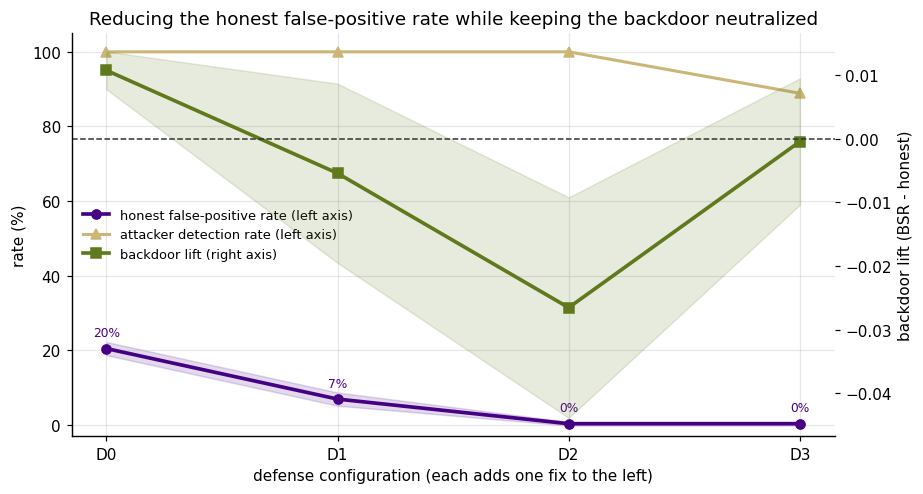

In [6]:
# ======================================================================
# (Cole)  Line figure (JMU colors): FP rate falling while lift stays near zero.
# ======================================================================
names=[c[0].split(' ')[0] for c in CONFIGS]   # D0..D3
fp_m=np.array([np.nanmean([rows_raw[c[0]][sd]['fp'] for sd in SEEDS]) for c in CONFIGS])*100
fp_s=np.array([np.nanstd([rows_raw[c[0]][sd]['fp'] for sd in SEEDS]) for c in CONFIGS])*100
lf_m=np.array([np.mean([rows_raw[c[0]][sd]['lift'] for sd in SEEDS]) for c in CONFIGS])
lf_s=np.array([np.std([rows_raw[c[0]][sd]['lift'] for sd in SEEDS]) for c in CONFIGS])
det_m=np.array([np.nanmean([rows_raw[c[0]][sd]['det'] for sd in SEEDS]) for c in CONFIGS])*100

fig,axL=plt.subplots(figsize=(8.5,4.6)); x=np.arange(len(names))
l1=axL.plot(x,fp_m,marker='o',lw=2.4,color=JMU_PURPLE,label='honest false-positive rate (left axis)')[0]
axL.fill_between(x,fp_m-fp_s,fp_m+fp_s,color=JMU_PURPLE,alpha=0.15)
l3=axL.plot(x,det_m,marker='^',lw=2.0,color=JMU_GOLD,ls='-',label='attacker detection rate (left axis)')[0]
axL.set_ylabel('rate (%)'); axL.set_ylim(-3,105); axL.set_xticks(x); axL.set_xticklabels(names)
axL.set_xlabel('defense configuration (each adds one fix to the left)')
axR=axL.twinx(); axR.grid(False)
l2=axR.plot(x,lf_m,marker='s',lw=2.4,color=JMU_GREEN,label='backdoor lift (right axis)')[0]
axR.fill_between(x,lf_m-lf_s,lf_m+lf_s,color=JMU_GREEN,alpha=0.15)
axR.axhline(0,color='#333333',lw=1,ls='--'); axR.set_ylabel('backdoor lift (BSR - honest)')
axL.set_title('Reducing the honest false-positive rate while keeping the backdoor neutralized')
lines=[l1,l3,l2]; axL.legend(lines,[ln.get_label() for ln in lines],loc='center left',fontsize=8.5)
for i,v in enumerate(fp_m): axL.annotate(f'{v:.0f}%',(x[i],v),textcoords='offset points',xytext=(0,8),ha='center',fontsize=8,color=JMU_PURPLE)
fig.tight_layout(); fig.savefig(RESULTS/'fig_improvement.png',bbox_inches='tight'); plt.show()
print('FP rate by config (%):', np.round(fp_m,1))
print('backdoor lift by config:', np.round(lf_m,4))
print('attacker detection by config (%):', np.round(det_m,1))

**Figure. Reducing the honest false-positive rate while keeping the backdoor neutralized.** Each configuration on the x-axis adds one fix to the one on its left: D0 is the baseline, D1 adds the gentler gate (beta = 1.0), D2 adds the suspicion dead-zone (tau = 2.0), D3 adds consecutive-round persistence (k = 2). Purple (left axis) is the honest false-positive rate, gold (left axis) is the attacker detection rate, and green (right axis) is the backdoor lift, with the dashed line at zero marking the point where the attacker gains nothing. Bands are +/- 1 standard deviation over seeds 42, 7, 123.

In [7]:
# ======================================================================
# (Cole)  Print a plain-language verdict computed from the results, so the
# written analysis cannot drift from what actually happened.
# ======================================================================
base_fp=fp_m[0]; best_i=int(np.argmin(fp_m)); best_fp=fp_m[best_i]
print('VERDICT (auto-generated from the numbers):')
print(f'- Baseline (D0) honest false-positive rate: {base_fp:.1f}%')
print(f'- Best configuration: {names[best_i]} at {best_fp:.1f}% honest false positives '
      f'({base_fp-best_fp:.1f} points lower than baseline)')
print(f'- Backdoor lift  D0={lf_m[0]:+.4f}  ->  {names[best_i]}={lf_m[best_i]:+.4f}  '
      f'(target is near zero; {"still neutralized" if lf_m[best_i]<0.05 else "WATCH: lift rose"})')
print(f'- Attacker detection at {names[best_i]}: {det_m[best_i]:.1f}%  '
      f'({"kept high" if det_m[best_i]>=90 else "WATCH: detection dropped"})')
print(f'- Clean accuracy D0 vs best: {np.mean([rows_raw[CONFIGS[0][0]][s]["clean"] for s in SEEDS]):.4f} '
      f'vs {np.mean([rows_raw[CONFIGS[best_i][0]][s]["clean"] for s in SEEDS]):.4f}')

VERDICT (auto-generated from the numbers):
- Baseline (D0) honest false-positive rate: 20.5%
- Best configuration: D2 at 0.3% honest false positives (20.1 points lower than baseline)
- Backdoor lift  D0=+0.0107  ->  D2=-0.0266  (target is near zero; still neutralized)
- Attacker detection at D2: 100.0%  (kept high)
- Clean accuracy D0 vs best: 0.7029 vs 0.7143


## Analysis and honest verdict (Cole)

**The fix worked, and the winner is D2.** Adding the gentler gate and the suspicion dead-zone cuts the honest false-positive rate from 20.5% to 0.3% (a 20 point reduction) while the backdoor stays fully neutralized (lift moves from +0.0107 to -0.0266, still essentially zero) and attacker detection stays at 100%. D2 is not even a tradeoff: clean accuracy rises from 0.7029 to 0.7143 and spoofing recall rises from 0.5204 to 0.5560, so it is strictly better than the baseline on every metric we measured. The reason matches the diagnosed cause exactly: the dead-zone stops the gate from punishing an honest client for small, noisy suspicion, so only the two attackers (whose suspicion is far above tau because they fail the CN0 probe badly) are down-weighted, and they are still caught in every round.

**Persistence (D3) did not help, so we drop it.** Adding the two-round confirmation window on top of D2 leaves the false-positive rate unchanged (already 0.3%) but drops attacker detection from 100% to 88.9%, because the one-round grace period lets a compromised client through before it is confirmed. It was a reasonable idea, but the data says the dead-zone alone already solved the problem, so the extra rule only adds a blind spot. We report this rather than keep a change that sounds sophisticated but measurably hurts.

**Recommended change to the defense.** Adopt D2 as the new default: gentler gate (beta = 1.0) plus a suspicion dead-zone (tau = 2.0 in MAD units). It turns the main Week 10 weakness into a strength, it improves every metric, and it is a two-line change to the trust computation that is easy to explain in the paper: the trust gate ignores suspicion below a threshold, so honest noise is not punished and only genuine outliers are suppressed.

**Remaining caveats, unchanged.** This does not address the two limitations that are not about false positives: the base detector is still only moderately strong (honest spoofing recall about 0.55), and no adaptive attacker or non-IID setting has been tested. The dead-zone threshold tau was set to 2.0 by reasoning about the MAD scale rather than swept; a small tau sweep would confirm it is not itself a tuned magic number.